# 模块四：分类问题与树模型
**案例背景**：分类预测。本 Notebook 涵盖逻辑回归、决策树、KNN、SVM 与朴素贝叶斯。

---

## 逻辑回归



来源: 面经知识库 01-linear-models.md §2.4 逻辑回归


In [6]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split



## 1. 模拟数据生成


In [7]:
np.random.seed(42)
n_samples = 200

# 类别 0: 未购买 (停留时间较短，点击次数较少)
time_0 = np.random.normal(5, 2, 100)
clicks_0 = np.random.normal(2, 1, 100)
y_0 = np.zeros(100)

# 类别 1: 购买 (停留时间较长，点击次数较多)
time_1 = np.random.normal(12, 3, 100)
clicks_1 = np.random.normal(6, 2, 100)
y_1 = np.ones(100)

# 合并数据
X = np.vstack((np.column_stack((time_0, clicks_0)), np.column_stack((time_1, clicks_1))))
y = np.concatenate((y_0, y_1))

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



## 2. 模型训练


In [8]:
model = LogisticRegression()
model.fit(X_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 3. 模型预测与评估


In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # 获取预测为正类的概率

print("--- 逻辑回归模型结果 ---")
print(f"准确率 (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("混淆矩阵:\n", confusion_matrix(y_test, y_pred))
print("分类报告:\n", classification_report(y_test, y_pred))



--- 逻辑回归模型结果 ---
准确率 (Accuracy): 1.00
混淆矩阵:
 [[21  0]
 [ 0 19]]
分类报告:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## 4. 决策边界可视化


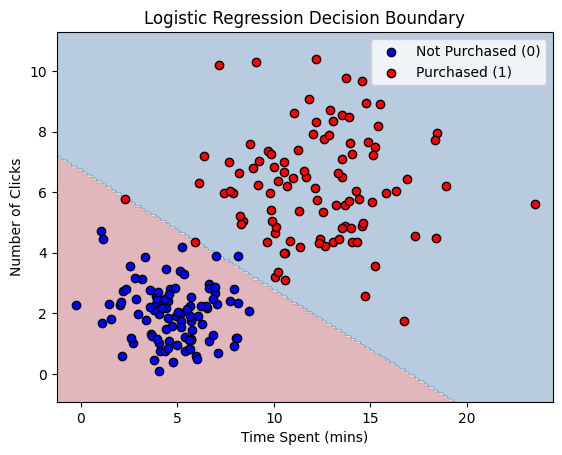

In [10]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Not Purchased (0)", color="blue", edgecolors="k")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Purchased (1)", color="red", edgecolors="k")
plt.xlabel("Time Spent (mins)")
plt.ylabel("Number of Clicks")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


# 树模型与 Boosting（Tree Models）

本笔记本合并了该主题下的多个小实验，按小节依次编排。



---

## 决策树



来源: 面经知识库 02-tree-models.md §1.4 决策树


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



## 1. 模拟数据生成


In [2]:
np.random.seed(42)
n_samples = 150

# 特征: 年龄 (20-70) 和 收入 (3k-50k)
age = np.random.uniform(20, 70, n_samples)
income = np.random.uniform(3, 50, n_samples)

# 目标: 是否购买理财产品。规则：年龄>40且收入>15，或者 年龄<=40且收入>30 容易购买
y = np.zeros(n_samples)
for i in range(n_samples):
    if (age[i] > 40 and income[i] > 15) or (age[i] <= 40 and income[i] > 30):
        y[i] = 1

# 增加一些噪声
flip_indices = np.random.choice(n_samples, int(0.1 * n_samples), replace=False)
y[flip_indices] = 1 - y[flip_indices]

X = np.column_stack((age, income))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



## 2. 模型训练


In [3]:
# 限制深度防止过拟合
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## 3. 模型预测与评估


In [4]:
y_pred = dt_model.predict(X_test)
print(f"决策树准确率: {accuracy_score(y_test, y_pred):.2f}")



决策树准确率: 0.87


## 4. 决策树可视化


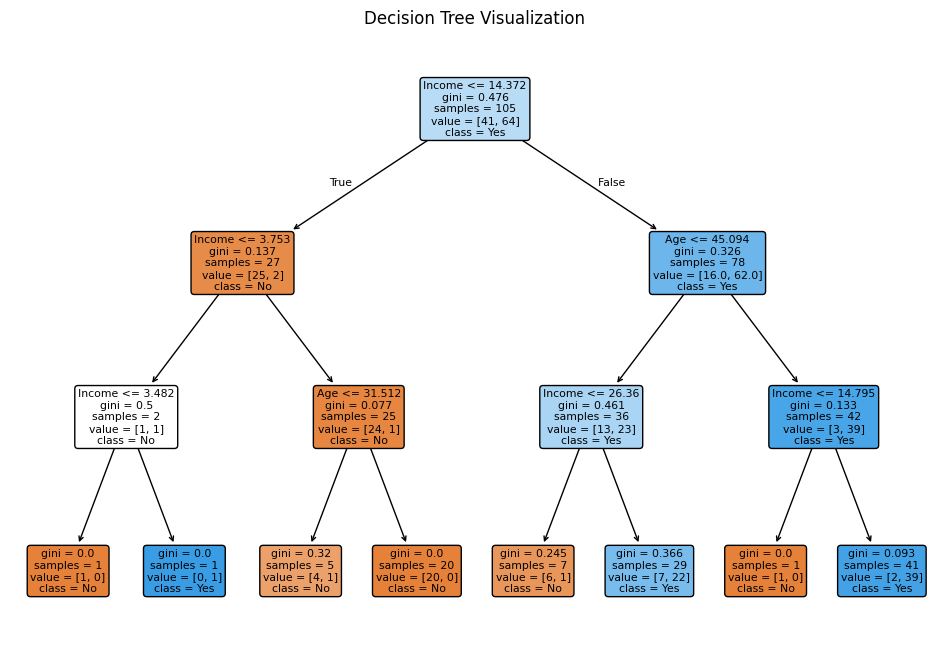

In [5]:
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=["Age", "Income"], class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


# 距离与概率模型（KNN / SVM / Naive Bayes）

本笔记本合并了该主题下的多个小实验，按小节依次编排。



---

## KNN



来源: 面经知识库 03-distance-models.md §1.4 KNN


In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler



## 1. 模拟数据生成


In [ ]:
np.random.seed(42)
# 女性数据 (类别 0): 身高 150-170, 体重 45-65
height_f = np.random.normal(160, 5, 50)
weight_f = np.random.normal(55, 5, 50)
y_f = np.zeros(50)

# 男性数据 (类别 1): 身高 165-185, 体重 60-85
height_m = np.random.normal(175, 5, 50)
weight_m = np.random.normal(75, 5, 50)
y_m = np.ones(50)

X = np.vstack((np.column_stack((height_f, weight_f)), np.column_stack((height_m, weight_m))))
y = np.concatenate((y_f, y_m))



## 2. 数据标准化 (KNN 必须步骤！)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## 3. 模型训练与预测


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, y)

# 预测一个新样本: 身高 168, 体重 62
new_sample = np.array([[168, 62]])
new_sample_scaled = scaler.transform(new_sample)
prediction = knn.predict(new_sample_scaled)

print(f"新样本预测类别: {'男性' if prediction[0] == 1 else '女性'}")



## 4. 可视化


In [ ]:
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="red", label="Female")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="blue", label="Male")
plt.scatter(new_sample[:, 0], new_sample[:, 1], color="green", marker="*", s=200, label="New Sample")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("KNN: Height & Weight vs Gender")
plt.legend()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


---

## SVM（RBF 核）



来源: 面经知识库 03-distance-models.md §2.4 SVM RBF


In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles



## 1. 生成非线性可分的环形数据


In [ ]:
X, y = make_circles(n_samples=300, factor=0.3, noise=0.1, random_state=42)



## 2. 模型训练 (使用 RBF 高斯核)


In [ ]:
svm_model = SVC(kernel="rbf", C=1.0, gamma="auto")
svm_model.fit(X, y)



## 3. 决策边界可视化


In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color="red", label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="blue", label="Class 1")

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_model.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors="k", levels=[-1, 0, 1], alpha=0.5, linestyles=["--", "-", "--"])
plt.title("SVM with RBF Kernel on Non-linear Data")
plt.legend()
if "agg" in mpl.get_backend().lower():
    plt.close("all")
else:
    plt.show()


---

## 朴素贝叶斯



来源: 面经知识库 03-distance-models.md §3.4 朴素贝叶斯


In [ ]:
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer



## 1. 模拟文本数据


In [ ]:
texts = [
    "free money win lottery",
    "claim your free prize now",
    "meeting at 10 am tomorrow",
    "project report attached",
    "win free tickets",
    "lunch tomorrow?",
]
labels = np.array([1, 1, 0, 0, 1, 0])



## 2. 文本特征提取 (词频统计)


In [ ]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)



## 3. 模型训练


In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X, labels)



## 4. 预测新邮件


In [ ]:
new_texts = ["free money now", "meeting tomorrow"]
X_new = vectorizer.transform(new_texts)
predictions = nb_model.predict(X_new)

print("--- 朴素贝叶斯文本分类 ---")
for text, pred in zip(new_texts, predictions):
    print(f"邮件内容: '{text}' -> 预测类别: {'垃圾邮件' if pred == 1 else '正常邮件'}")
